# Dominant Poles

In [1]:
import requests as req, os
URL = "https://raw.githubusercontent.com/mit-acl/16_06_Class/main/"
File = ["basic_material.py","control_materials.py","read_csv_data.py"]
try:
    %run basic_material.py
    print('Basic file found')
except:    
    print('Basic files not` found - downloading it')
    for dfile in File:
        if not os.path.isfile(dfile):
            print(dfile)
            res = req.get(URL+dfile)
            file = open(dfile, 'w')
            file.write(res.text)
            file.close()

try:
    from control.matlab import tf,step, tf2ss, ss2tf, bode
except:
    !python3 -m pip install control
    from control.matlab import tf,step
import control as ct

import scipy
from scipy.signal import residue

Running Python: 3.8.17
Running Sympy: 1.12rc1
Basic file found


## Simple Example

In [2]:
s = tf('s')
# slow system
P = 10/(s/1+1)
# Add faster dynamics
P1 = P*1/(s/2+1)
P2 = P*1/(s/10+1)

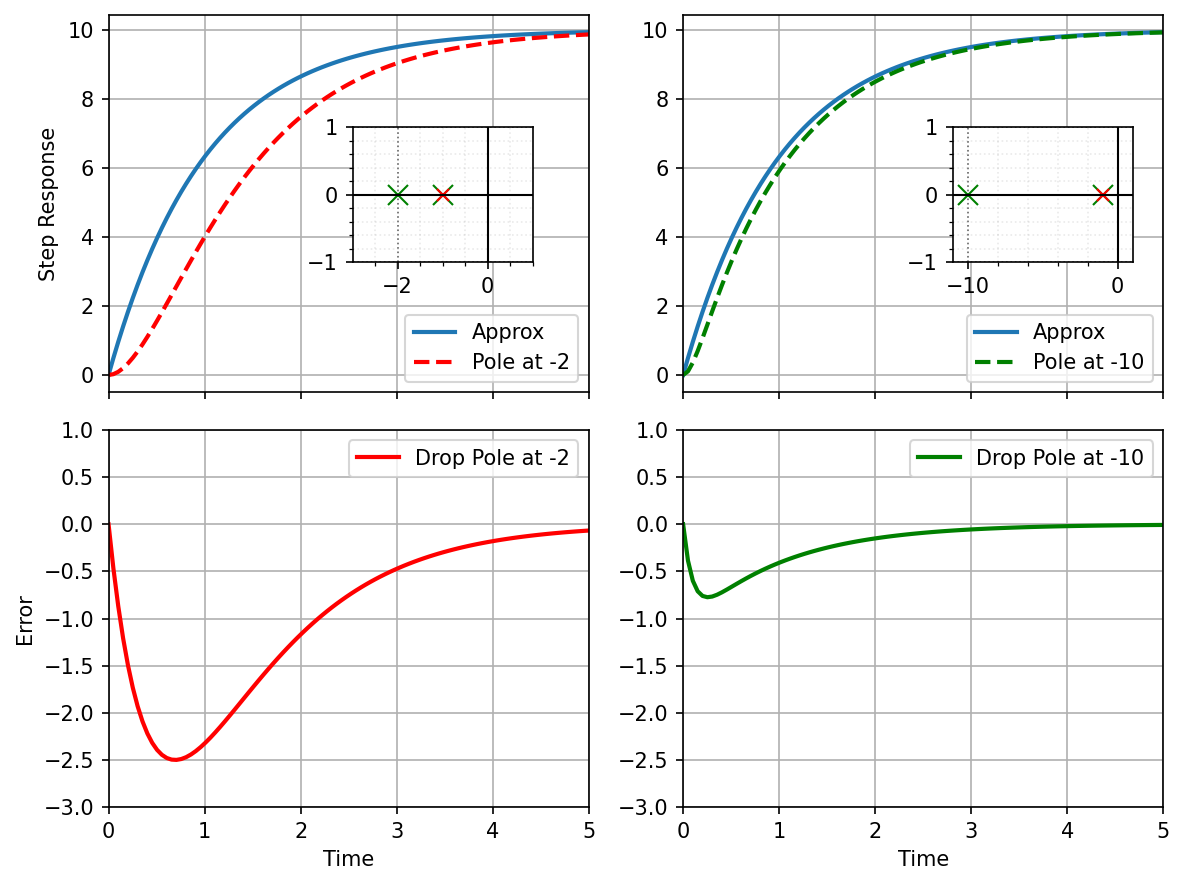

In [3]:
fig, ax = plt.subplots(2,2,figsize=(8, 6),dpi=150,sharex = True)
yap,t = step(P,5)
y1,t = step(P1,t)
y2,t = step(P2,t)

ax[0][0].plot(t,yap,label='Approx')
ax[0][1].plot(t,yap,label='Approx')
ax[0][0].plot(t,y1,'r--',label='Pole at -2')
ax[0][1].plot(t,y2,'g--',label='Pole at -10')
ax[1][0].plot(t,y1-yap,'r-',label='Drop Pole at -2')
ax[1][1].plot(t,y2-yap,'g-',label='Drop Pole at -10')
ax[0][0].set_ylabel("Step Response")
ax[1][0].set_ylabel("Error")

left, bottom, width, height = [0.3, 0.7, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(P1.poles()),np.imag(P1.poles()), 'x', ms=10, color='green')
ax2.plot(np.real(P.poles()),np.imag(P.poles()), 'rx', ms=6, color='red')
ax2.set_xlim((-3,1))
ax2.set_ylim((-1,1))
nicegrid(ax2)

left, bottom, width, height = [0.8, 0.7, 0.15, 0.15]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.figure.set_facecolor('w')
ax3.plot(np.real(P2.poles()),np.imag(P2.poles()), 'x', ms=10, color='green')
ax3.plot(np.real(P.poles()),np.imag(P.poles()), 'rx', ms=6, color='red')
ax3.set_xlim((-11,1))
ax3.set_ylim((-1,1))
nicegrid(ax3)

[ax[1][x].set_ylim((-3,1)) for x in range(2)]
[ax[x][y].legend() for x in range(2) for y in range(2)]
[ax[1][x].set_xlabel("Time") for x in range(2)]
savefig("./figs/DP_Ex1.pdf", dpi=600)
plt.show()

## More Complex Example

In [4]:
s = tf('s')
# slow system
P = 1/(s+1)
# add faster system
P1 = 10**2/(s**2+2*s + 10**2) * P
P2 = P*1/(s/10+1)*1/(s/11+1)

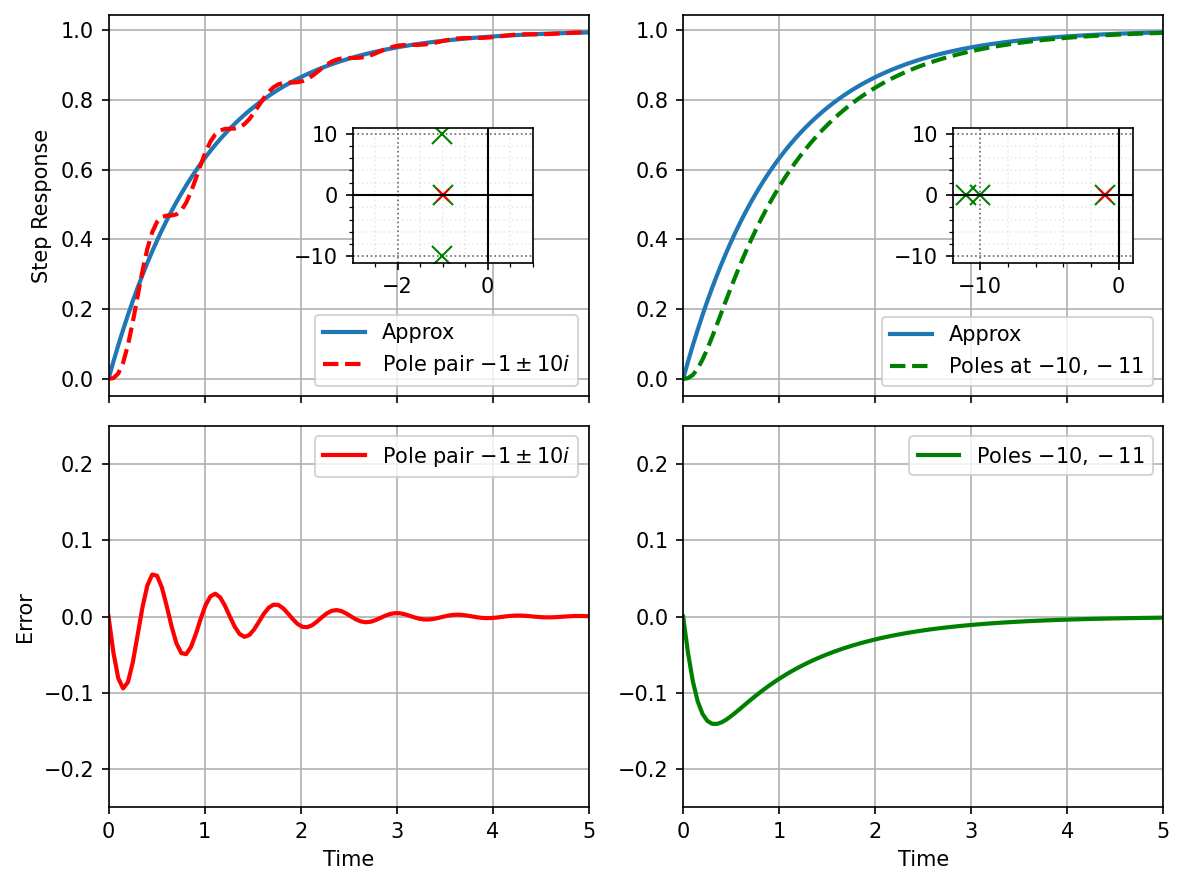

In [5]:
fig, ax = plt.subplots(2,2,figsize=(8, 6),dpi=150,sharex = True)
yap,t = step(P,5)
y1,t = step(P1,t)
y2,t = step(P2,t)

ax[0][0].plot(t,yap,label='Approx')
ax[0][1].plot(t,yap,label='Approx')
ax[0][0].plot(t,y1,'r--',label=r'Pole pair $-1\pm 10i$')
ax[0][1].plot(t,y2,'g--',label='Poles at $-10,-11$')
ax[1][0].plot(t,y1-yap,'r-',label=r'Pole pair $-1\pm 10i$')
ax[1][1].plot(t,y2-yap,'g-',label=r'Poles $-10,-11$')
ax[0][0].set_ylabel("Step Response")
ax[1][0].set_ylabel("Error")

left, bottom, width, height = [0.3, 0.7, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(P1.poles()),np.imag(P1.poles()), 'x', ms=10, color='green')
ax2.plot(np.real(P.poles()),np.imag(P.poles()), 'rx', ms=6, color='red')
ax2.set_xlim((-3,1))
ax2.set_ylim((-11,11))
nicegrid(ax2)

left, bottom, width, height = [0.8, 0.7, 0.15, 0.15]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.figure.set_facecolor('w')
ax3.plot(np.real(P2.poles()),np.imag(P2.poles()), 'x', ms=10, color='green')
ax3.plot(np.real(P.poles()),np.imag(P.poles()), 'rx', ms=6, color='red')
ax3.set_xlim((-12,1))
ax3.set_ylim((-11,11))
nicegrid(ax3)

[ax[1][x].set_ylim((-.25,.25)) for x in range(2)]
[ax[x][y].legend() for x in range(2) for y in range(2)]
[ax[1][x].set_xlabel("Time") for x in range(2)]
savefig("./figs/DP_Ex2.pdf", dpi=600)
plt.show()

## With Zeros

In [6]:
s = tf('s')
# slow
P = 1/(s+1)
# add faster with a zero
P1 = (s/1.1+1)/(s/10+1) * P
P2 = (s/2.1+1)/(s/2+1) * P

yap,t = step(P,5)
y1,t = step(P1,t)
y2,t = step(P2,t)

In [7]:
scipy.signal.residue(P1.num[0][0],P1.den[0][0])

(array([   0.101,    8.990]),
 array([  -1.000,  -10.000]),
 array([], dtype=float64))

In [8]:
from sympy import latex
ss = Symbol('s')
sP = 1/(ss+1)
sP1 = (ss/1.1+1)/(ss/10+1) * sP
sP2 = (ss/2.1+1)/(ss/2+1) * sP
print(latex(sP1.apart()))

\frac{0.101010101010101}{s + 1} + \frac{0.898989898989899}{0.1 s + 1.0}


In [9]:
print(latex(sP2.apart()))

\frac{1.04761904761905}{s + 1} - \frac{0.0476190476190476}{0.5 s + 1.0}


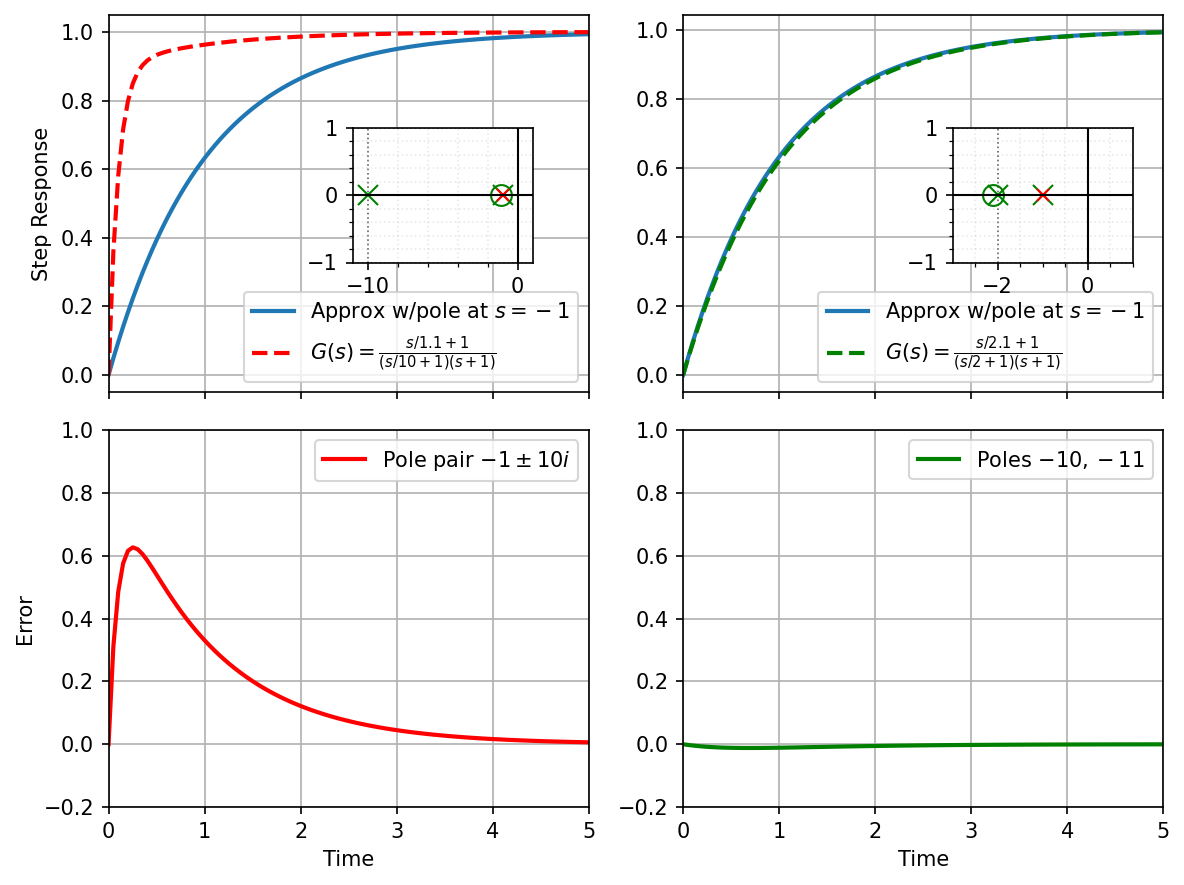

In [10]:
fig, ax = plt.subplots(2,2,figsize=(8, 6),dpi=150,sharex = True)

[ax[0][x].plot(t,yap,label=r'Approx w/pole at $s=-1$') for x in range(2)]
ax[0][0].plot(t,y1,'r--',label=r'$G(s) = \frac{s/1.1+1}{(s/10+1)(s+1)}$')
ax[0][1].plot(t,y2,'g--',label=r'$G(s) = \frac{s/2.1+1}{(s/2+1)(s+1)}$')
ax[1][0].plot(t,y1-yap,'r-',label=r'Pole pair $-1\pm 10i$')
ax[1][1].plot(t,y2-yap,'g-',label=r'Poles $-10,-11$')
ax[0][0].set_ylabel("Step Response")
ax[1][0].set_ylabel("Error")

left, bottom, width, height = [0.3, 0.7, 0.15, 0.15]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.figure.set_facecolor('w')
ax2.plot(np.real(P1.poles()),np.imag(P1.poles()), 'x', ms=10, color='green')
ax2.plot(np.real(P1.zeros()),np.imag(P1.zeros()), 'o', markerfacecolor='none', ms=10, color='green')
ax2.plot(np.real(P.poles()),np.imag(P.poles()), 'rx', ms=6, color='red')
ax2.set_xlim((-11,1))
ax2.set_ylim((-1,1))
nicegrid(ax2)

left, bottom, width, height = [0.8, 0.7, 0.15, 0.15]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.figure.set_facecolor('w')
ax3.plot(np.real(P2.poles()),np.imag(P2.poles()), 'x', ms=10, color='green')
ax3.plot(np.real(P2.zeros()),np.imag(P2.zeros()), 'o', markerfacecolor='none', ms=10, color='green')
ax3.plot(np.real(P.poles()),np.imag(P.poles()), 'rx', ms=6, color='red')
ax3.set_xlim((-3,1))
ax3.set_ylim((-1,1))
nicegrid(ax3)

[ax[1][x].set_ylim((-.2,1)) for x in range(2)]
[ax[x][y].legend() for x in range(2) for y in range(2)]
[ax[1][x].set_xlabel("Time") for x in range(2)]
savefig("./figs/DP_Ex3.pdf", dpi=600)
plt.show()